Running Gillespie simulation of Oosawa model
  kn = 1e-04,  ka = 1e-02,  nc = 2,  m0 = 200
  Simulation ended at t = 23.03
  Final state:  m = 0,  P = 18,  M = 200
  Total events simulated: 182
Plot saved to oosawa_gillespie.png


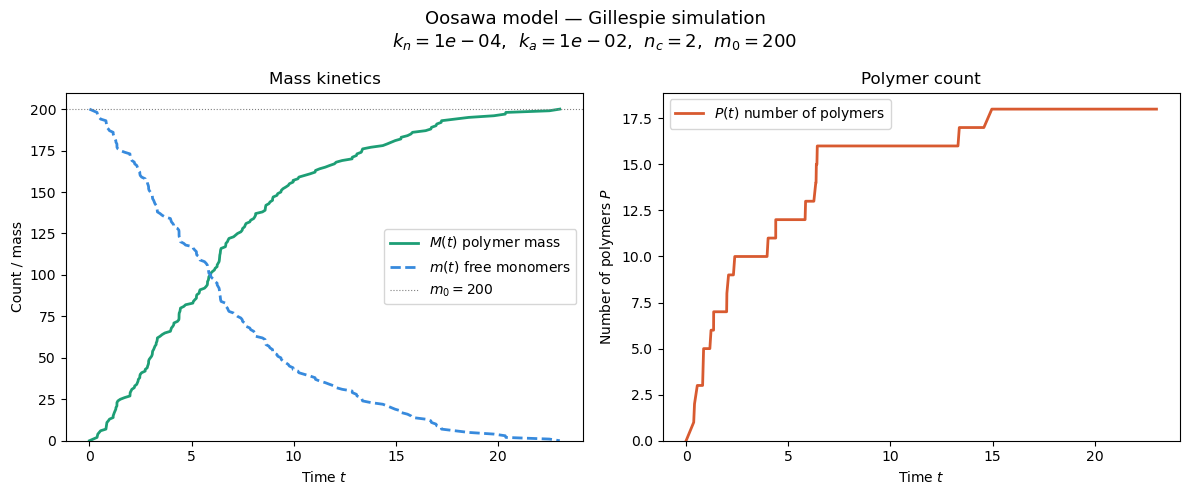

In [3]:
"""
Oosawa Model - Gillespie Stochastic Simulation
================================================
Week 1: Physics of Protein Aggregation

Model reactions:
  Nucleation:   nc monomers → polymer of size nc,  rate = kn * m(t)^nc
  Association:  polymer(j) + monomer → polymer(j+1), rate = ka * m(t) per polymer

State variables:
  m(t) = free monomers = m0 - M(t)
  P(t) = number of polymers  (changes only via nucleation)
  M(t) = total polymer mass  (changes via nucleation and association)
"""

import numpy as np
import matplotlib.pyplot as plt


def gillespie_oosawa(kn, ka, nc, m0, max_events=50000):
    """
    Gillespie simulation of the Oosawa model (Nucleation + Association).

    Parameters
    ----------
    kn         : float  - nucleation rate constant
    ka         : float  - association rate constant
    nc         : int    - critical nucleus size (number of monomers needed)
    m0         : int    - initial number of free monomers
    max_events : int    - maximum number of reaction events to simulate

    Returns
    -------
    t_series : list of float - time points
    m_series : list of int   - free monomer count at each time
    P_series : list of int   - number of polymers at each time
    M_series : list of int   - total polymer mass at each time
    """

    # --- Initial conditions ---
    t = 0.0
    m = m0    # free monomers
    P = 0     # number of polymers
    M = 0     # total polymer mass

    t_series = [t]
    m_series = [m]
    P_series = [P]
    M_series = [M]

    rng = np.random.default_rng()

    for _ in range(max_events):

        # --- Step 1: Calculate reaction rates ---
        # Nucleation: nc monomers must collide simultaneously
        r_nucl = kn * (m ** nc) if m >= nc else 0.0

        # Association: each existing polymer can recruit one monomer
        r_assoc = ka * m * P if m > 0 and P > 0 else 0.0

        r_total = r_nucl + r_assoc

        if r_total <= 0:
            break  # no more reactions possible

        # --- Step 2: Sample time until next event (exponential distribution) ---
        tau = -np.log(rng.random()) / r_total
        t += tau

        # --- Step 3: Choose which reaction fires ---
        u = rng.random()

        if u < r_nucl / r_total:
            # --- Nucleation: consume nc monomers, create one new polymer ---
            m -= nc
            M += nc
            P += 1
        else:
            # --- Association: consume 1 monomer, add to an existing polymer ---
            m -= 1
            M += 1
            # P does not change (no new polymer created)

        # --- Step 4: Record state ---
        t_series.append(t)
        m_series.append(m)
        P_series.append(P)
        M_series.append(M)

        if m <= 0:
            break  # all monomers consumed

    return t_series, m_series, P_series, M_series


def plot_results(t, m, P, M, m0, kn, ka, nc):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(
        f"Oosawa model — Gillespie simulation\n"
        f"$k_n={kn:.0e}$,  $k_a={ka:.0e}$,  $n_c={nc}$,  $m_0={m0}$",
        fontsize=13
    )

    # --- Left panel: M(t) and m(t) ---
    ax = axes[0]
    ax.plot(t, M, color="#1D9E75", lw=2, label="$M(t)$ polymer mass")
    ax.plot(t, m, color="#378ADD", lw=2, ls="--", label="$m(t)$ free monomers")
    ax.axhline(m0, color="gray", lw=0.8, ls=":", label=f"$m_0 = {m0}$")
    ax.set_xlabel("Time $t$")
    ax.set_ylabel("Count / mass")
    ax.set_title("Mass kinetics")
    ax.legend(fontsize=10)
    ax.set_ylim(bottom=0)

    # --- Right panel: P(t) ---
    ax = axes[1]
    ax.plot(t, P, color="#D85A30", lw=2, label="$P(t)$ number of polymers")
    ax.set_xlabel("Time $t$")
    ax.set_ylabel("Number of polymers $P$")
    ax.set_title("Polymer count")
    ax.legend(fontsize=10)
    ax.set_ylim(bottom=0)

    plt.tight_layout()
    plt.savefig("oosawa_gillespie.png", dpi=150, bbox_inches="tight")
    print("Plot saved to oosawa_gillespie.png")
    plt.show()


# =============================================================================
# Run the simulation
# =============================================================================
if __name__ == "__main__":

    # --- Parameters ---
    KN = 1e-4    # nucleation rate constant (slow)
    KA = 1e-2    # association rate constant (fast)
    NC = 2       # critical nucleus size
    M0 = 200     # initial monomers

    print(f"Running Gillespie simulation of Oosawa model")
    print(f"  kn = {KN:.0e},  ka = {KA:.0e},  nc = {NC},  m0 = {M0}")

    t, m, P, M = gillespie_oosawa(kn=KN, ka=KA, nc=NC, m0=M0, max_events=100_000)

    print(f"  Simulation ended at t = {t[-1]:.2f}")
    print(f"  Final state:  m = {m[-1]},  P = {P[-1]},  M = {M[-1]}")
    print(f"  Total events simulated: {len(t) - 1}")

    plot_results(t, m, P, M, m0=M0, kn=KN, ka=KA, nc=NC)